<a href="https://colab.research.google.com/github/Datdeptrai912005/DemoGit/blob/main/MLLM_Qwen_Trend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes datasets

Mounted at /content/drive
  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-8o3qgsh4/unsloth_7eb8d460d1c24c1f98c10a99f9f9dfff
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-8o3qgsh4/unsloth_7eb8d460d1c24c1f98c10a99f9f9dfff
  Resolved https://github.com/unslothai/unsloth.git to commit b65a7450ca6091c230e0d8c721182b2ff7d20718
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 428.0/428.0 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.

In [3]:
from datasets import load_dataset
from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "chatml",
)

def formatting_prompts_func(examples):
    convos = examples["messages"]
    texts = [tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False) for convo in convos]
    return { "text" : texts }

train_dataset = load_dataset("json", data_files="/content/drive/MyDrive/train_data.jsonl", split="train")
test_dataset = load_dataset("json", data_files="/content/drive/MyDrive/test_data.jsonl", split="train")
train_dataset = train_dataset.map(formatting_prompts_func, batched=True)
test_dataset = test_dataset.map(formatting_prompts_func, batched=True)

print(f"📚 Đã nạp {len(train_dataset)} mẫu để Dạy (Train)")
print(f"📝 Đã nạp {len(test_dataset)} mẫu để Kiểm tra (Test)")

Unsloth: Will map <|im_end|> to EOS = <|im_end|>.


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/5924 [00:00<?, ? examples/s]

Map:   0%|          | 0/659 [00:00<?, ? examples/s]

📚 Đã nạp 5924 mẫu để Dạy (Train)
📝 Đã nạp 659 mẫu để Kiểm tra (Test)


In [2]:
from unsloth import FastLanguageModel
import torch
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-1.5B-Instruct",
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)
print("✅ Tải mô hình thành công ")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.5.2 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


✅ Tải mô hình thành công 


In [4]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = test_dataset,
    dataset_text_field = "text",
    max_seq_length = 2048,
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 10,
        num_train_epochs = 1,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 20,
        eval_strategy = "steps",
        eval_steps = 100,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    ),
)
trainer_stats = trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/5924 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/659 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,924 | Num Epochs = 1 | Total steps = 741
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
100,1.714384,1.597931
200,1.845202,1.565771
300,1.790607,1.553980
400,1.608437,1.543449
500,1.661110,1.534489
600,1.905232,1.529430
700,1.590926,1.525133
741,1.801296,1.524618


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

In [5]:
save_path = "/content/drive/MyDrive/MLLA /Qwen_FakeNews_Model"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"✅ Đã lưu thành công trí tuệ của mô hình tại: {save_path}")

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/MLLA /Qwen_FakeNews_Model/tokenizer_config.json.


✅ Đã lưu thành công trí tuệ của mô hình tại: /content/drive/MyDrive/MLLA /Qwen_FakeNews_Model


Đang tải lại mô hình Qwen từ Drive...
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Đang tải dữ liệu test
Bắt đầu cho Qwen làm đề thi gồm 659 câu (Sẽ mất vài phút)...


  0%|          | 0/659 [00:00<?, ?it/s]The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=10) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask 

Đã phân tích xong biểu đồ đang được hoàn thiện 


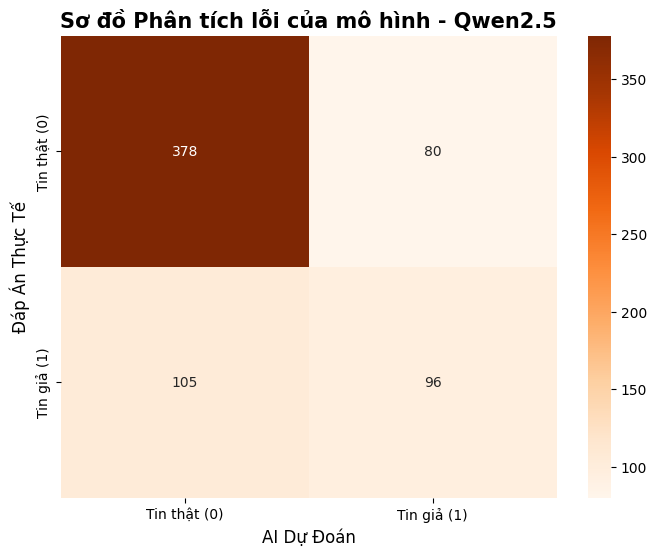

In [10]:
from unsloth import FastLanguageModel
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

print("Đang tải lại mô hình Qwen từ Drive...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "/content/drive/MyDrive/MLLA /Qwen_FakeNews_Model",
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model)

print("Đang tải dữ liệu test")
test_dataset = load_dataset("json", data_files="/content/drive/MyDrive/test_data.jsonl", split="train")

y_true = []
y_pred = []

print(f"Bắt đầu cho Qwen làm đề thi gồm {len(test_dataset)} câu (Sẽ mất vài phút)...")
for item in tqdm(test_dataset):
    # Lấy đáp án thật từ file json
    true_label = next(msg["content"] for msg in item["messages"] if msg["role"] == "assistant")
    y_true.append(int(true_label))

    # Lấy nội dung tin tức cần kiểm tra
    user_text = next(msg["content"] for msg in item["messages"] if msg["role"] == "user")

    # Thiết lập ngữ cảnh cho AI
    messages = [
        {"role": "system", "content": "Phân tích tin giả."},
        {"role": "user", "content": user_text}
    ]

    # Đưa vào mô hình để suy luận
    inputs = tokenizer.apply_chat_template(messages, tokenize=True, add_generation_prompt=True, return_tensors="pt").to("cuda")
    outputs = model.generate(input_ids=inputs, max_new_tokens=10, use_cache=True, pad_token_id=tokenizer.eos_token_id)
    response = tokenizer.batch_decode(outputs)[0]

    # Cắt lấy phần câu trả lời của AI
    pred_str = response.split("<|im_start|>assistant\n")[-1].replace("<|im_end|>", "").strip()

    if "1" in pred_str:
        y_pred.append(1)
    else:
        y_pred.append(0)

print("Đã phân tích xong biểu đồ đang được hoàn thiện ")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Tin thật (0)', 'Tin giả (1)'],
            yticklabels=['Tin thật (0)', 'Tin giả (1)'])

plt.title('Sơ đồ Phân tích lỗi của mô hình - Qwen2.5', fontsize=15, fontweight='bold')
plt.xlabel('AI Dự Đoán', fontsize=12)
plt.ylabel('Đáp Án Thực Tế', fontsize=12)

plt.show()